<a href="https://colab.research.google.com/github/michalis0/DataScience_and_MachineLearning/blob/master/08-Recommenders/08_Recommenders_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics.pairwise import cosine_similarity


# Recommender Systems


<img src='https://imgs.xkcd.com/comics/star_ratings.png' width="300">

Source: [xkcd 1908](https://xkcd.com/1098/)

### Goal
In this exercise, we will be proceeding in two stages.
1. The first stage is where we get into the details of how to build our own recommender system to recommend movies to users.
2. In the second stage, we will be an existing library, specialized for recommender systems, which provides more powerful options. We will be testing it on the task of recommending jokes to users.

### What you are learning in this exercise:
1. Getting familiar with item-based collaborative filtering and user-based collaborative filtering.
2. Getting familiar with an existing library for recommender systems.

### Content

The goal of this walkthrough is to guide you through implementing and evaluating a basic recommender system. A [recommender system](https://en.wikipedia.org/wiki/Recommender_system) is a type of information filtering system designed to predict a user’s preference for an item, often used in commercial applications to suggest products, movies, or other items.

In this notebook, we will cover:

- [Task 1: Exploring the MovieLens Dataset with Implicit Feedback](#Task-1-Exploring-the-MovieLens-Dataset-with-Implicit-Feedback)
  - [Step 1: Load the Data](#Step-1-Load-the-Data)
  - [Step 2: Check the Number of Interactions, Users, and Movies](#Step-2-Check-the-Number-of-Interactions-Users-and-Movies)
  - [Step 3: Split the Data into Training and Test Sets](#Step-3-Split-the-Data-into-Training-and-Test-Sets)
  
- [Task 2: Creating User-Item Matrices for Implicit Feedback](#Task-2-Creating-User-Item-Matrices-for-Implicit-Feedback)
  - [Step 1: Define the Function to Create the Data Matrix](#Step-1-Define-the-Function-to-Create-the-Data-Matrix)
  - [Step 2: Create the Training and Testing Matrices](#Step-2-Create-the-Training-and-Testing-Matrices)
  - [Step 3: Visualize the User-Item Interaction Matrices](#Step-3-Visualize-the-User-Item-Interaction-Matrices)

- [Task 3: Item-to-Item Collaborative Filtering with Implicit Feedback](#Task-3-Item-to-Item-Collaborative-Filtering-with-Implicit-Feedback)
  - [Step 1: Compute Item Similarity Matrix](#Step-1-Compute-Item-Similarity-Matrix)
  - [Step 2: Predict Positive Interactions Using Item Similarity](#Step-2-Predict-Positive-Interactions-Using-Item-Similarity)

- [Task 4: User-to-User Collaborative Filtering with Implicit Feedback](#Task-4-User-to-User-Collaborative-Filtering-with-Implicit-Feedback)
  - [Step 1: Compute User Similarity Matrix](#Step-1-Compute-User-Similarity-Matrix)
  - [Step 2: Predict Positive Interactions Using User Similarity](#Step-2-Predict-Positive-Interactions-Using-User-Similarity)

- [Task 5: Evaluating Our Recommenders](#Task-5-Evaluating-Our-Recommenders)
  - [Step 5.1: Precision@K and Recall@K](#Step-5.1-Precision@K-and-Recall@K)
  - [Step 5.2: Implement Precision@K and Recall@K](#Step-5.2-Implement-Precision@K-and-Recall@K)

- [Task 6: Show the Recommendations for a Specific User](#Task-6-Show-the-Recommendations-for-a-Specific-User)
  - [Step 6.1: Select a User and Get Recommendations](#Step-6.1-Select-a-User-and-Get-Recommendations)
  - [Step 6.2: Create Recommendation DataFrames with TMDb IDs](#Step-6.2-Create-Recommendation-DataFrames-with-TMDb-IDs)
  - [Step 6.3: Fetching and Displaying Movie Posters](#Step-6.3-Fetching-and-Displaying-Movie-Posters)

## Task 1: Exploring the MovieLens Dataset with Implicit Feedback




In this part, we’ll be using the [MovieLens dataset](https://grouplens.org/datasets/movielens/). ‌We will use the Movielens-small dataset that contains 100,000 interactions of users with different movies. An interaction of a user with a movie is when a user rates a movie with a value from 1 to 5. In this walkthrough we want to focus on **implicit feedback** recommendation scenario, i.e., we are interested in the items that each user liked, or interacted with. Therefore, we have provided you with a subset of interactions in the dataset that contains the ratings larger than or equal to 4.

#### Step 1: Load the Data

We’ll start by loading the datasets in the `data` folder. We have 3 datasets here:
- `interactions.csv`
- `movies.csv`
- `links.csv`


In [ ]:
# Load the datasets
base_url = "https://raw.githubusercontent.com/charleliebrun-afk/ML-BROMET-BRUN/87b14e8d13483b707fc94db41bc47da4f8469bf6/kaggle_data"

interactions_train_url = f"{base_url}/interactions_train.csv"

items_url = f"{base_url}/items.csv"

sample_submission_url = f"{base_url}/sample_submission.csv"

interactions_train = pd.read_csv(interactions_train_url)

items = pd.read_csv(items_url)

sample_submission = pd.read_csv(sample_submission_url)
# Display the first rows of each dataset
display(interactions_train.head())
display(items.head())
display(sample_submission.head())


,u,i,t
0,4456,8581,1.687541e+09
1,142,1964,1.679585e+09
2,362,3705,1.706872e+09
3,1809,11317,1.673533e+09
4,4384,1323,1.681402e+09


,Title,Author,ISBN Valid,Publisher,Subjects,i
0,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0
1,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,1
2,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,2
3,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,3
4,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,4


,user_id,recommendation
0,0,3758 11248 9088 9895 5101 6074 9295 14050 1096...
1,1,3263 726 1589 14911 6432 10897 6484 7961 8249 ...
2,2,13508 9848 12244 2742 11120 2893 2461 5439 116...
3,3,2821 10734 6357 5934 2085 12608 12539 10551 10...
4,4,12425 219 11602 1487 14178 489 13888 2110 4413...


__Can you understand the information contained in each of the tables above?__


#### Step 2: Check the Number of interactions, users and movies

Let’s check how many unique users and items we have in this dataset.

In [ ]:
n_users = interactions_train.u.nunique()
n_items = interactions_train.i.nunique()
print(f'Number of users = {n_users}, \n Number of items = {n_items} \n Number of interactions = {len(interactions_train)}')


Number of users = 7838, 
 Number of items = 15109 
 Number of interactions = 87047



#### Step 3: Split the Data into Training and Test Sets

Splitting the data to training and test sets for recommendation systems is different from what you have seen in other classification/regression problems. In recommender systems, we want to make recommendations (predictions) for each user. Therefore, we need to make sure that we have training and test data for each user. In other words, we have to split the interactions of each user to training and test sets. For instance, if we want to do 80-20 splitting, we need to make sure that we have 80% of each user's interactions in the training set and the remaining 20% in the test set.

Moreover, to have a splitting that is more aligned with the reality, it is better to do the splitting based on the timestamp of the interactions (if the timestamp data is available). To do so, we have to sort the interactions of each user based on time, and pick the first 80% interactions in the training set and the last 20% interactions in the test set. This is more aligned with the reality as we always want to predict the future interactions of a user, that is, *the items that the user might like in the future*.

The figure below can help you understand better how this splitting is done.



<img src='https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/09-recommender-systems/data/image/train-test-split-reco.png' width="700">

In [ ]:
# let's first sort the interactions by user and time stamp
user_books = interactions_train.merge(items, on='i')
user_books = user_books.sort_values(["u", "t"])
user_books.head(10)

,u,i,t,Title,Author,ISBN Valid,Publisher,Subjects
21035,0,0,1.680191e+09,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...
28842,0,1,1.680783e+09,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...
3958,0,2,1.680801e+09,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...
29592,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...
6371,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...
41220,0,4,1.686569e+09,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...
12217,0,5,1.687014e+09,100 idées pour mieux gérer les troubles de l'a...,"Lussier, Francine",9782353450428; 2353450423,Tom Pousse,Trouble déficitaire de l'attention avec ou san...
19703,0,6,1.687014e+09,La boîte à outils des formateurs : 71 outils...,"Bouchut, Fabienne",9782100806614; 2100806610; 9782100846023; 2100...,Dunod,Formateurs (éducation des adultes)--Formation...
64522,0,7,1.687014e+09,L'autorité éducative dans la classe : douze si...,"Robbes, Bruno",9782710121152; 2710121158,ESF éd,autorité--relation maître-élève; autorité--ens...
29380,0,8,1.687260e+09,Un autre regard sur le climat /,Emma dessinatrice 1981-....,9791097160821,Massot,Climat--Détérioration; Bandes dessinées


Next we can use the percentage rank from pandas to get a proportional ranking of the timestamps for each user. Check the documentation on how to use the `rank` funciton with groupby in pandas (https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.rank.html#pandas.core.groupby.DataFrameGroupBy.rank).

In [ ]:
user_books["pct_rank"] = user_books.groupby("u")["t"].rank(pct=True, method='dense')
user_books.reset_index(inplace=True, drop=True)
user_books.head(5)

,u,i,t,Title,Author,ISBN Valid,Publisher,Subjects,pct_rank
0,0,0,1.680191e+09,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0.04
1,0,1,1.680783e+09,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,0.08
2,0,2,1.680801e+09,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,0.12
3,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,0.16
4,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,0.20


Now all remains to do is to pick the first 80% of the interactions of each user in the training set and the rest in the test set. We can do so using the `pct_rank` column.

In [ ]:
# time-based split: first 80% of each user's history → train, last 20% → test
train_data = user_books[user_books["pct_rank"] < 0.8]
test_data = user_books[user_books["pct_rank"] >= 0.8]

In [ ]:
print("Training set size:", train_data.shape[0])
print("Testing set size:", test_data.shape[0])


Training set size: 65419
Testing set size: 21628


## Task 2: Creating User-Item Matrices for Implicit Feedback


In [ ]:

print('number of users =', n_users, '| number of items =', n_items)

number of users = 7838 | number of items = 15109


#### Step 1: Define the Function to Create the Data Matrix

Next, we’ll define a function that creates the user-item data matrix. Each matrix cell will contain a 1 if there was an interaction and a 0 otherwise.


In [ ]:
def create_data_matrix(data, n_users, n_items, use_decay=False, lambda_decay=0.00001):
    data_matrix = np.zeros((n_users, n_items))

    if use_decay:
        t_max = data["t"].max()
        decay = np.exp(-lambda_decay * (t_max - data["t"].values))
        data_matrix[data["u"].values, data["i"].values] = decay
    else:
        data_matrix[data["u"].values, data["i"].values] = 1

    return data_matrix

#### Step 2: Create the Training and Testing Matrices

Now we can use the function to create matrices for both the training and testing data. Each cell in the matrix will show a 1 if there was a positive interaction in the training or testing data, and a 0 otherwise.

In [ ]:

# Recalcul correct

n_users = max(train_data["u"].max(), test_data["u"].max()) + 1

n_items = max(train_data["i"].max(), test_data["i"].max()) + 1

def create_data_matrix(data, n_users, n_items):

    data_matrix = np.zeros((n_users, n_items))

    data_matrix[data["u"].values, data["i"].values] = 1

    return data_matrix


# Create the training and testing matrices
train_data_matrix = create_data_matrix(train_data, n_users, n_items)
test_data_matrix = create_data_matrix(test_data, n_users, n_items)

# Display the matrices to understand their structure
print('train_data_matrix')
print(train_data_matrix)
print("number of non-zero values: ", np.sum(train_data_matrix))
print('test_data_matrix')
print(test_data_matrix)
print("number of non-zero values: ", np.sum(test_data_matrix))


train_data_matrix
[[1. 1. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  49689.0
test_data_matrix
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
number of non-zero values:  19409.0


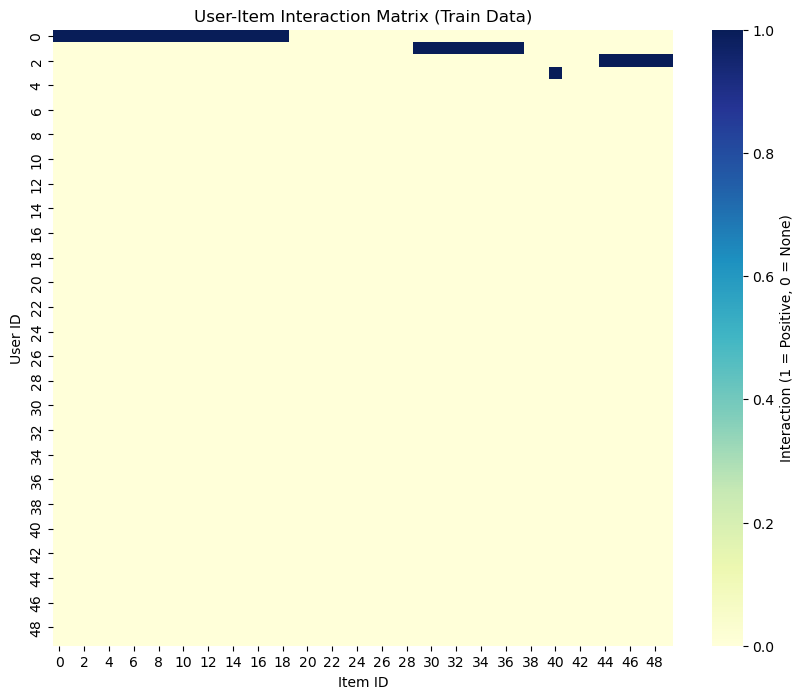

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot a heatmap for a subset of the user-item matrix
def plot_interaction_heatmap(data_matrix, title, num_users=50, num_items=50):

    # Extract a subset of the matrix for visualization purposes
    matrix_subset = data_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Interaction (1 = Positive, 0 = None)'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the training and testing matrices
plot_interaction_heatmap(train_data_matrix, 'User-Item Interaction Matrix (Train Data)')



## Task 3: Item-to-Item Collaborative Filtering with Implicit Feedback

Now that we’ve prepared our data, our next task is to create a recommender system using **Item-to-Item Collaborative Filtering**. In this context, the recommendation translates to “Users who liked this item (movie) also liked …”.

Since we’re working with implicit feedback, the prediction formula will focus on the **likelihood of positive interactions** rather than ratings. This will predict items the user may interact with based on similarities to items they’ve previously liked.

The following formula shows how to compute the likelihood of interaction between a user $u$ and item $i$ using item-to-item colaborative filtering.

\begin{equation}
{p}_{u}(i) =  \frac{\sum\limits_{i' \in I} \text{sim}(i, i') \cdot {R}_{u}(i')}{\sum\limits_{i' \in I} \text{sim}(i, i')}
\end{equation}

In the above formula:


*   $P_u(i)$ is the likelihood of user $u$ interacting with item $i$. This is the value we want to compute.
*   $\text{sim}(i, i')$ is the cosine similarity between items $i$ and $i'$.
*   $R_u(i')$ is one if user $u$ has already interacted with item $i'$. Otherwise it is zero.
*   $I$ is the set of all items in the dataset.

The value $P_u(i)$ is expected to be between 0 and 1.



#### Step 1: Compute Item Similarity Matrix

As a first step, we’ll calculate the pairwise similarity matrix between all items using **cosine similarity**. This matrix will show how similar each item is to every other item based on the interaction patterns of users. The output will be an `n_items` by `n_items` symmetric 2D numpy matrix.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the item-item similarity matrix
# Check sklearn documentation for cosine similarity to understand how we are
# using this function.
item_similarity = cosine_similarity(train_data_matrix.T)
print("Item-Item Similarity Matrix:")
print(item_similarity)
print(item_similarity.shape)


Item-Item Similarity Matrix:
[[1.         0.40824829 0.33333333 ... 0.         0.         0.        ]
 [0.40824829 1.         0.40824829 ... 0.         0.         0.        ]
 [0.33333333 0.40824829 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]
(15291, 15291)


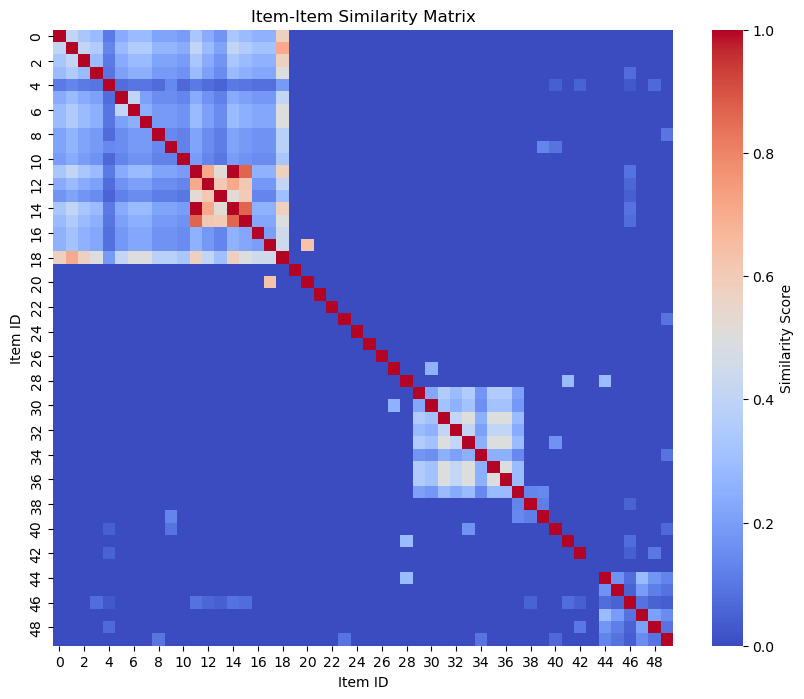

In [ ]:
# Function to visualize the item similarity matrix
def plot_item_similarity_heatmap(similarity_matrix, title, num_items=50):

    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_items, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('Item ID')
    plt.ylabel('Item ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the item similarity matrix
plot_item_similarity_heatmap(item_similarity, 'Item-Item Similarity Matrix')


Let's have a look at the 2 items that have a similarity of one. Do you think they are actually similar? What do you think has happened here?

#### Step 2: Predict Positive Interactions Using Item Similarity

Next, we’ll use the item similarity matrix to predict the likelihood of positive interactions for each user with each item.

In what follows, we create a function that implements the above formula for item-to-item cf recommendation.

In [ ]:


# Define the function to predict interactions based on item similarity
def item_based_predict(interactions, similarity, epsilon=1e-9):

    # np.dot does the matrix multiplication. Here we are calculating the
    # weighted sum of interactions based on item similarity
    pred = similarity.dot(interactions.T) / (similarity.sum(axis=1)[:, np.newaxis] + epsilon)
    return pred.T  # Transpose to get users as rows and items as columns

# Calculate the item-based predictions for positive interactions
item_prediction = item_based_predict(train_data_matrix, item_similarity)
print("Predicted Interaction Matrix:")
print(item_prediction)
print(item_prediction.shape)

Predicted Interaction Matrix:
[[0.46097255 0.85435984 0.71867834 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


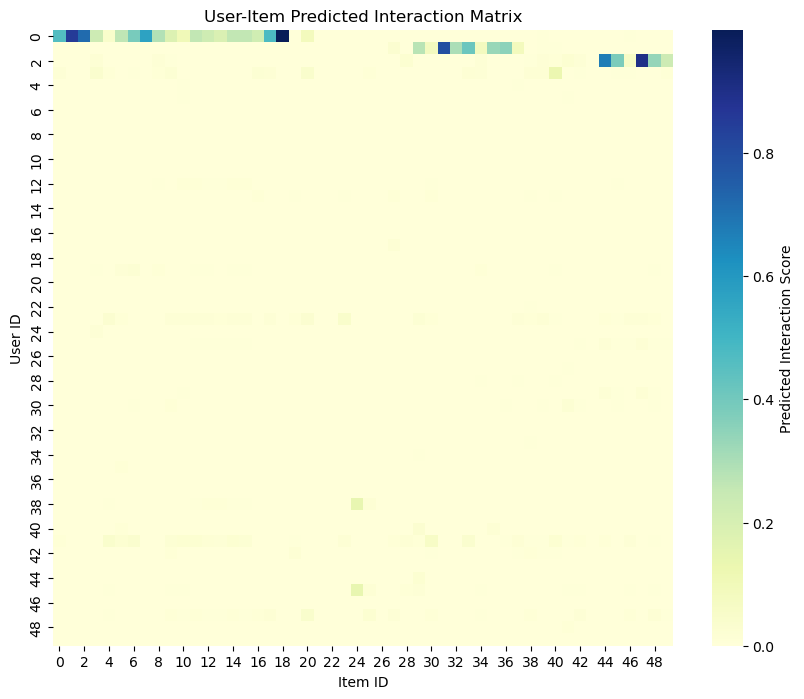

In [ ]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=50, num_items=50):

    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(item_prediction, 'User-Item Predicted Interaction Matrix')



In this setup:
- The `item_based_predict` function calculates a score for each user-item pair using the item-to-item colaborative filtering formula.
- The result is a prediction matrix where each cell indicates the predicted likelihood of an interaction between each user and item.

## Task 4: User-to-User Collaborative Filtering with Implicit Feedback

In this task, we’ll create a recommender system using **User-to-User Collaborative Filtering**. This approach translates to “Users who are similar to you also liked…”. We’ll predict the likelihood of a user interacting with an item based on the behavior of similar users.


#### Step 1: Compute User Similarity Matrix

To start, we’ll compute the similarity matrix between users using **cosine similarity**. This matrix shows how similar each user is to every other user based on their interaction patterns. This will create a `num_users * num_users` matrix.

In [ ]:
# Compute the user-user similarity matrix
user_similarity = cosine_similarity(train_data_matrix)
print("User-User Similarity Matrix:")
print(user_similarity)

# Check the shape as a sanity check
print("Shape of User Similarity Matrix:", user_similarity.shape)


User-User Similarity Matrix:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Shape of User Similarity Matrix: (7838, 7838)


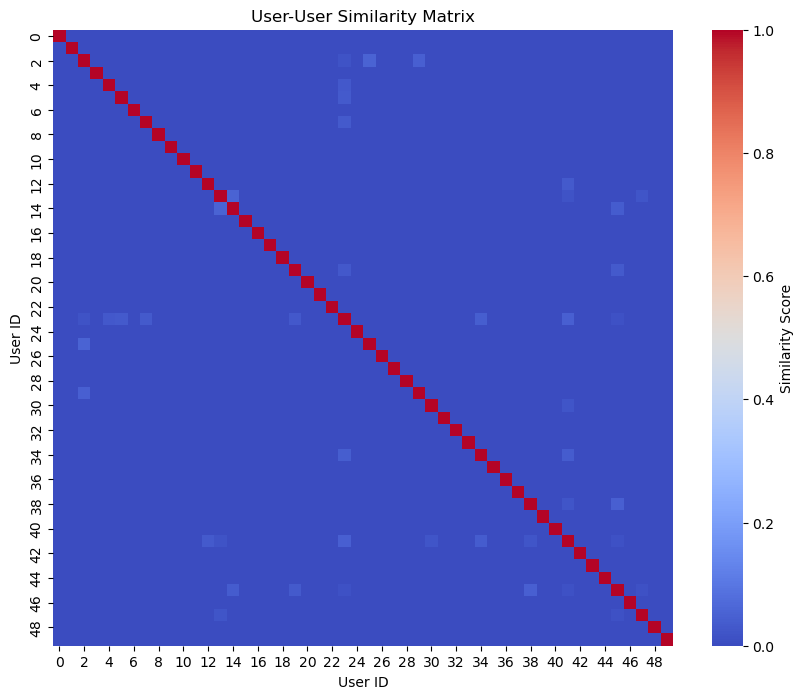

In [ ]:
# Function to plot the user similarity matrix
def plot_user_similarity_heatmap(similarity_matrix, title, num_users=50):

    # Extract a subset of the matrix for visualization
    matrix_subset = similarity_matrix[:num_users, :num_users]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="coolwarm", cbar=True, cbar_kws={'label': 'Similarity Score'})
    plt.xlabel('User ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# visualize a subset of the user similarity matrix
plot_user_similarity_heatmap(user_similarity, 'User-User Similarity Matrix')


### Step 2: Predict Positive Interactions Using User Similarity

Next, we’ll use the user similarity matrix to predict the likelihood of positive interactions for each user with each item. Since we’re working with implicit feedback, we’ll calculate a score for each item based on binary interaction values (1 for positive interactions, 0 for none).

The prediction formula is as follows:

\begin{equation}
{p}_{u}(i) = \frac{\sum\limits_{u' \in U} \text{sim}(u, u') \cdot {R}_{u'}(i)}{\sum\limits_{u' \in U} \text{sim}(u, u')}
\end{equation}


#### Explanation:
*   $P_u(i)$ is the likelihood of user $u$ interacting with item $i$. This is the value we want to compute.
*   $\text{sim}(u, u')$ is the cosine similarity between users $u$ and $u'$.
*   $R_u'(i)$ is one if user $u'$ has already interacted with item $i$. Otherwise it is zero.
*   $U$ is the set of all users in the dataset.


This formula calculates the likelihood of interaction between user $ u $ and item $ i $ based on interactions of similar users with that item. The weighted sum of interactions from similar users is normalized by the sum of the similarities.

- **`similarity.dot(interactions)`**: Calculates the weighted sum of interactions for each user, based on similar users’ interactions.
- **`np.abs(similarity).sum(axis=1)[:, np.newaxis]`**: The denominator normalizes the prediction by the sum of absolute similarities to avoid bias from users with more neighbors.
- **`epsilon`**: Prevents division by zero, which could result in `NaN` values.

In [ ]:
# Define the function to predict interactions based on user similarity
def user_based_predict(interactions, similarity, epsilon=1e-9):

    # Calculate the weighted sum of interactions based on user similarity
    pred = similarity.dot(interactions) / (np.abs(similarity).sum(axis=1)[:, np.newaxis] + epsilon)
    return pred

# Calculate the user-based predictions for positive interactions
user_prediction = user_based_predict(train_data_matrix, user_similarity)
print("Predicted Interaction Matrix (User-Based):")
print(user_prediction)
print(user_prediction.shape)


Predicted Interaction Matrix (User-Based):
[[0.13171649 0.13259591 0.14274867 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(7838, 15291)


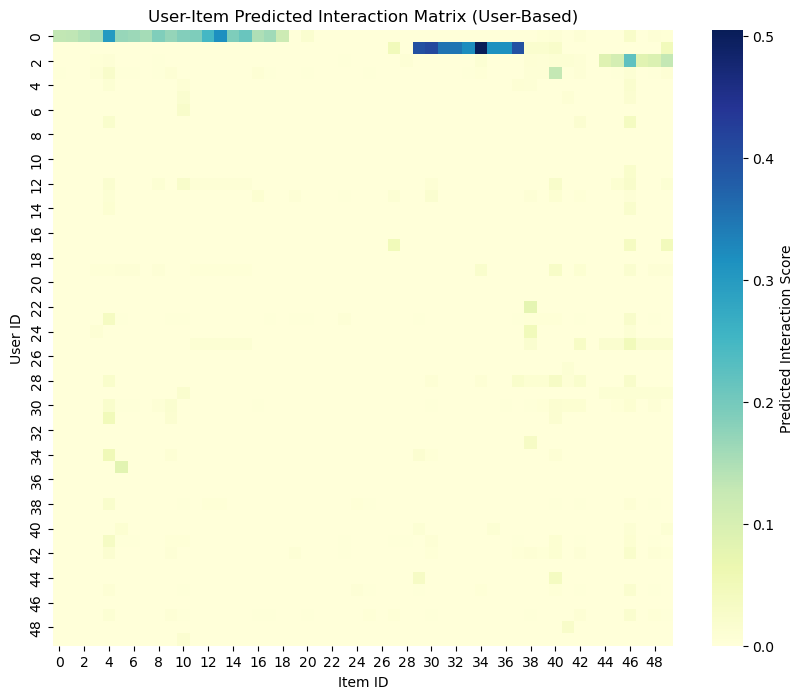

In [ ]:
# Function to visualize the predicted interaction matrix for a subset of users and items
def plot_interaction_prediction_heatmap(prediction_matrix, title, num_users=50, num_items=50):

    # Extract a subset of the matrix for visualization
    matrix_subset = prediction_matrix[:num_users, :num_items]

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_subset, cmap="YlGnBu", cbar=True, cbar_kws={'label': 'Predicted Interaction Score'})
    plt.xlabel('Item ID')
    plt.ylabel('User ID')
    plt.title(title)
    plt.show()

# Visualize a subset of the predicted interaction matrix
plot_interaction_prediction_heatmap(user_prediction, 'User-Item Predicted Interaction Matrix (User-Based)')


## Task 5: Evaluating Our Recommenders

#### Ranking Accurarcy (Precision@K and Recall@K)

An implicit recommendation system is a ranking system which ranks items for each user based on their relevance to the user. Therefore, to evaluate such system, we’re interested in the quality of the top ranked recommendations rather than the actual predicted score for each recommendation. **Precision@K** and **Recall@K** focus on the top-K items recommended for each user, measuring relevance of the top-ranked recommended items to a user.

- **Precision@K**: Measures the proportion of relevant items in the top-K recommendations.
  
  \begin{equation}
  \text{Precision@K} = \frac{\text{Number of relevant items in top-K}}{K}
  \end{equation}

- **Recall@K**: Measures the proportion of actual relevant items that appear in the top-K recommendations.

  \begin{equation}
  \text{Recall@K} = \frac{\text{Number of relevant items in top-K}}{\text{Total number of relevant items}}
  \end{equation}

Recall@k and Precision@k are metrics that are computed per user. To have a single value to evaluate a recommender system as a whole, we can take the average of Recall@K and Precision@K among all of the users.

### Your Turn !

As an exercise, complete the function precision_recall_at_k below to calculate Precision@K and Recall@K for a given value of K. Follow the instructions provided in the function to fill in the missing parts.

In [ ]:
#Defining the precision/recall function

def precision_recall_at_k(prediction, ground_truth, k=10):

    num_users = prediction.shape[0]
    precision_at_k, recall_at_k = 0, 0

    for user in range(num_users):
        # Get the indices of the top-K items for the user based on predicted scores
        # np.argsort to get the top-K items for the current user
        top_k_items = np.argsort(prediction[user])[::-1][:k]

        # Step 2: Calculate the number of relevant items in the top-K items for the user
        # TODO: Count how many of the top-K items are actually relevant (i.e., present in ground truth)
        relevant_items_in_top_k = np.sum(ground_truth[user, top_k_items])  # Complete this line to count relevant items in top-K

        # Step 3: Calculate the total number of relevant items for the user
        # TODO: Sum the total relevant items in the ground_truth for this user
        total_relevant_items = np.sum(ground_truth[user])  # Complete this line to get the total relevant items

        # Update Precision@K and Recall@K for this user
        precision_at_k += relevant_items_in_top_k / k
        recall_at_k += relevant_items_in_top_k / total_relevant_items if total_relevant_items > 0 else 0

    # Step 4: Calculate the average Precision@K and Recall@K over all users
    precision_at_k /= num_users
    recall_at_k /= num_users

    return precision_at_k, recall_at_k


After completing the function, you can calculate Precision@K and Recall@K for the user-based and item-based predictions as follows:



In [ ]:
precision_user_k, recall_user_k = precision_recall_at_k(user_prediction, test_data_matrix, k=10)
precision_item_k, recall_item_k = precision_recall_at_k(item_prediction, test_data_matrix, k=10)

print('User-based CF Precision@K:', precision_user_k)
print('User-based CF Recall@K:', recall_user_k)
print('Item-based CF Precision@K:', precision_item_k)
print('Item-based CF Recall@K:', recall_item_k)


User-based CF Precision@K: 0.056532278642513596
User-based CF Recall@K: 0.2906567293761024
Item-based CF Precision@K: 0.05561367695841055
Item-based CF Recall@K: 0.26399361388179715


## Task 6: Show the Recommendations for a Specific User

Pick a user at random. Extract the top-10 recommendations for this user by both the User-to-User and Item-to-Item Collaborative Filtering models. Present the recommendations by showing the movie posters.

__Hint:__ You can get the movie posters from the TMDb API. In the `links` DataFrame, you’ll find the TMDb ID corresponding to each movie. Using this ID, retrieve the movie poster and display it.

In [ ]:
import numpy as np
import pandas as pd

# takes any prediction matrix and exports the top-k book IDs per user as a CSV
def generate_recommendation_csv(prediction_matrix, train_matrix=None, k=10, filename="final_sub.csv", reverse=True):
    recommendations_list = []

    prediction_matrix = prediction_matrix.copy()

    # do not recommend books you have already seen!
    if train_matrix is not None:
        prediction_matrix[train_matrix > 0] = -np.inf if reverse else np.inf

    for user_id in range(prediction_matrix.shape[0]):

        if reverse:
            top_k_indices = np.argsort(prediction_matrix[user_id])[::-1][:k]
        else:
            top_k_indices = np.argsort(prediction_matrix[user_id])[::-1][:k]

        rec_string = " ".join(map(str, top_k_indices))

        recommendations_list.append({
            "user_id": user_id,
            "recommendation": rec_string
        })

    df_recos = pd.DataFrame(recommendations_list)
    df_recos.to_csv(filename, index=False)
    return df_recos

In [ ]:
import sklearn.feature_extraction.text
# All ids

all_item_ids = np.arange(n_items)
df_all_items = pd.DataFrame({'i': all_item_ids})

# join ids on the authors dataframe
df_authors = user_books[['i', 'Author']].drop_duplicates('i')
df_final_content = pd.merge(df_all_items, df_authors, on='i', how='left')

# Fill the Nan values with Unknow_Author
df_final_content['Author'] = df_final_content['Author'].fillna('Unknown_Author')

# Put the authors in a vector
vectorizer = sklearn.feature_extraction.text.CountVectorizer(tokenizer=lambda x: [x], lowercase=False)
author_matrix = vectorizer.fit_transform(df_final_content['Author'])

# generating the similarity matrix :(n_items, n_items)
S_content = cosine_similarity(author_matrix)

print(S_content.shape)

(15291, 15291)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
url_4 = "https://raw.githubusercontent.com/charleliebrun-afk/ML-BROMET-BRUN/9aaa1f7c26814e2ee1bd6c4282f52bf2b2b81967/items_with_categories.csv"



items_cat = pd.read_csv(url_4)
items_cat.head(5)
print(items_cat.shape)

(15291, 7)


In [ ]:
user_cat = interactions_train.merge(items_cat, on='i')
user_cat = user_cat.sort_values(["u", "t"])
user_cat.head(10)

,u,i,t,Title,Author,ISBN Valid,Publisher,Subjects,Catégorie
21035,0,0,1.680191e+09,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,Library Science & Documentation
28842,0,1,1.680783e+09,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,Education & Pedagogy
3958,0,2,1.680801e+09,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,History
29592,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,Comics & Graphic Novels
6371,0,3,1.683715e+09,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,Comics & Graphic Novels
41220,0,4,1.686569e+09,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,Literature & Fiction
12217,0,5,1.687014e+09,100 idées pour mieux gérer les troubles de l'a...,"Lussier, Francine",9782353450428; 2353450423,Tom Pousse,Trouble déficitaire de l'attention avec ou san...,Children's Literature
19703,0,6,1.687014e+09,La boîte à outils des formateurs : 71 outils...,"Bouchut, Fabienne",9782100806614; 2100806610; 9782100846023; 2100...,Dunod,Formateurs (éducation des adultes)--Formation...,Education & Pedagogy
64522,0,7,1.687014e+09,L'autorité éducative dans la classe : douze si...,"Robbes, Bruno",9782710121152; 2710121158,ESF éd,autorité--relation maître-élève; autorité--ens...,Education & Pedagogy
29380,0,8,1.687260e+09,Un autre regard sur le climat /,Emma dessinatrice 1981-....,9791097160821,Massot,Climat--Détérioration; Bandes dessinées,Comics & Graphic Novels


In [ ]:
n_users = user_cat.u.max() + 1
n_items = user_cat.i.max() + 1
print(f' Number of users = {n_users}, \n Number of books = {n_items} \n Number of interactions = {len(user_cat)}')

final_data_matrix_cat = create_data_matrix(user_cat, n_users, n_items)

 Number of users = 7838, 
 Number of books = 15291 
 Number of interactions = 87047


In [ ]:
import sklearn.feature_extraction.text
all_item_ids = np.arange(n_items)
df_all_items = pd.DataFrame({'i': all_item_ids})

# join ids on the categories dataframe
df_cat = user_cat[['i', 'Catégorie']].drop_duplicates('i')
df_final_cat = pd.merge(df_all_items, df_cat, on='i', how='left')

# Fill the Nan values with Unknow_cat
df_final_cat['Catégorie'] = df_final_cat['Catégorie'].fillna('Unknown_cat')

# Put the cat in a vector
vectorizer = sklearn.feature_extraction.text.CountVectorizer(tokenizer=lambda x: [x], lowercase=False)
cat_matrix = vectorizer.fit_transform(df_final_cat['Catégorie'])

# generating the similarity matrix :(n_items, n_items)
S_cat = cosine_similarity(cat_matrix)

print(S_cat.shape)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(15291, 15291)


In [ ]:
# Time-weighted loans
# preferences change over time: a recent loan is a better predictor of the next loan than a loan from two years ago.
# we replace the binary 0/1 matrix with a matrix where each interaction is weighted by exp(-lambda * (t_max - t)).
# Half-life = 180 days → lambda = ln(2) / (180 * 86400) ≈ 4.46e-8
# A loan from 6 months ago is worth 0.50; one from 1 year ago is worth 0.25.

import numpy as np
import gc

def create_data_matrix_decay(data, n_users, n_items, half_life_days=180):

    lambda_decay = np.log(2) / (half_life_days * 86400)  # en secondes
    t_max = data['t'].max()
    weights = np.exp(-lambda_decay * (t_max - data['t'].values))
    data_matrix = np.zeros((n_users, n_items), dtype='float32')
    np.add.at(data_matrix, (data['u'].values, data['i'].values), weights)
    return data_matrix

# time-weighted matrix (replaces the binary matrix for predictions)
final_data_matrix = create_data_matrix_decay(user_books, n_users, n_items, half_life_days=180)

# S_collab: item-to-item similarity on the weighted matrix
from sklearn.metrics.pairwise import cosine_similarity
S_collab = cosine_similarity(final_data_matrix.T)

print(f'final_data_matrix shape: {final_data_matrix.shape}')
print(f'Poids min (emprunt le plus ancien): {final_data_matrix[final_data_matrix > 0].min():.4f}')
print(f'Poids max (emprunt le plus récent): {final_data_matrix.max():.4f}')
print(f'Poids moyen (interactions non nulles): {final_data_matrix[final_data_matrix > 0].mean():.4f}')
print(f'S_collab shape: {S_collab.shape}')
gc.collect()


final_data_matrix shape: (7838, 15291)
Poids min (emprunt le plus ancien): 0.0815
Poids max (emprunt le plus récent): 21.4824
Poids moyen (interactions non nulles): 0.3784
S_collab shape: (15291, 15291)


17072

In [ ]:
S_collab = S_collab.astype('float32')
S_content = S_content.astype('float32')
S_cat = S_cat.astype('float32')

# original weights restored (base = 0.1615 on the leaderboard)
w_collab  = 0.80
w_content = 0.15
w_cat     = 0.05

S_content_global = (w_collab * S_collab) + (w_content * S_content) + (w_cat * S_cat)

print(f'S_content_global shape: {S_content_global.shape}')


S_content_global shape: (15291, 15291)


In [ ]:
import gc

# Correction: Use `final_data_matrix` instead of `train_data_matrix` (binary, 80% of the data) for `S_item` and `S_user`.

# A. Item-Item: Similarity on the full, time-weighted dataset
S_item = cosine_similarity(final_data_matrix.T).astype('float32')
P_item = final_data_matrix.dot(S_item)
del S_item
gc.collect()

# B. User-User : similarity based on time-weighted complete data
S_user = cosine_similarity(final_data_matrix).astype('float32')
P_user = S_user.dot(final_data_matrix)
del S_user
gc.collect()

# C. Content-Based
S_content = S_content_global.astype('float32')
del S_content_global
P_content = final_data_matrix.dot(S_content)
del S_content
gc.collect()

print('P_item, P_user, P_content calculés — matrices de similarité libérées.')


P_item, P_user, P_content calculés — matrices de similarité libérées.


## Improvement: Sequential Pattern

**Key observation**: Users borrow books sequentially from the catalog.
For example, a user who has borrowed book `n` has an 8.1% chance of borrowing book `n+1`,
and 26.2% of transitions occur within a range of ±5 IDs.

**Solution**: Construct a **transition matrix** `S_seq[i, j]` = the probability that book `j`
is borrowed immediately after book `i`, estimated based on the entire interaction history.
This captures the sequential browsing behavior on the library shelves.

In [ ]:
import gc
from scipy.sparse import lil_matrix, csr_matrix

def build_transition_matrix_sparse(interactions_df, n_items):

    T = lil_matrix((n_items, n_items), dtype=np.float32)

    for u, grp in interactions_df.groupby('u'):
        items = grp.sort_values('t')['i'].values
        for a, b in zip(items[:-1], items[1:]):
            if a != b and a < n_items and b < n_items:
                T[a, b] += 1

    T = T.tocsr()

    row_sums = np.array(T.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1
    from scipy.sparse import diags
    T = diags(1.0 / row_sums).dot(T)

    return T.astype('float32')

S_seq = build_transition_matrix_sparse(interactions_train, n_items)
print(f'Matrice sparse : {S_seq.shape}')
print(f'Entrées non nulles : {S_seq.nnz:,}  (vs {n_items**2:,} en dense)')
print(f'Mémoire économisée : {(1 - S_seq.nnz / n_items**2)*100:.1f}%')
gc.collect()

Matrice sparse : (15291, 15291)
Entrées non nulles : 64,179  (vs 233,814,681 en dense)
Mémoire économisée : 100.0%


0

In [ ]:
# Sequential prediction using a sparse matrix
# final_data_matrix (dense) @ S_seq (sparse)
P_seq = final_data_matrix.dot(S_seq.toarray())
del S_seq
gc.collect()
print(f'P_seq shape: {P_seq.shape}')
print(f'Score max: {P_seq.max():.4f} | Score moyen (non nul): {P_seq[P_seq > 0].mean():.4f}')

P_seq shape: (7838, 15291)
Score max: 10.0763 | Score moyen (non nul): 0.0528


In [ ]:
w1 = 0.05   # Poids User-User
w2 = 0.05   # Poids Item-Item
w3 = 0.70   # Poids Content-Based
w4 = 0.20   # Poids Séquentiel (nouveau)

# finaal fusion
P_final = (w1 * P_user) + (w2 * P_item) + (w3 * P_content) + (w4 * P_seq)
print('Prediction matrix computed with sequential pattern.')

Prediction matrix computed with sequential pattern.


In [ ]:
# generate the final submission file with our best model
df_final_dim = generate_recommendation_csv(
    P_final,
    k=10,
    filename="final_sub.csv"
)